# Tilt Axis Finder — walkthrough

Step-by-step run of `tilt_axis_finder.py` so you can inspect each intermediate result (raw frames, centroids, PCA, angle sweep) before trusting the final estimate.

Edit the `PATH` (and optionally `TLT_FILE`) in the next code cell, then run cells top to bottom.

In [1]:
%matplotlib inline
import sys

import numpy as np
import matplotlib.pyplot as plt
import hyperspy.api as hs

# tilt_axis_finder.py lives next to this notebook in the repo root
sys.path.insert(0, ".")
import tilt_axis_finder as taf

## 1. Load the tilt series

Set `PATH` to your tilt-series file (`.mrc`, `.st`, `.dm4`, tif stack, …). If you have a companion IMOD-style `.tlt`/`.rawtlt` file with the actual tilt angles, point `TLT_FILE` at it — otherwise leave it `None` and the navigation axis values (or frame index) are used for labeling only. The angle values aren't used by the estimation itself.

In [2]:
PATH = r'C:\My Files\OneDrive - Universiteit Antwerpen\GitHub\py5DED\other_scripts\navigation_signal_1.hspy'  # <-- edit me
TLT_FILE = None

data, tilt_angles, signal = taf.load_tilt_series(PATH, TLT_FILE)
tilt_angles = np.arange(-50,30, 0.2)
print(f"data shape: {data.shape}  (n_tilts, ny, nx)")
print(f"tilt angle range: {tilt_angles.min():.1f} to {tilt_angles.max():.1f} deg")
signal

data shape: (400, 512, 512)  (n_tilts, ny, nx)
tilt angle range: -50.0 to 29.8 deg


<Signal2D, title: , dimensions: (400|512, 512)>

## 2. Sanity-check a few raw frames

Quick look at the first, middle, and last tilt images — confirms the stack loaded correctly and gives you a feel for how much the specimen shifts/rotates across the series.

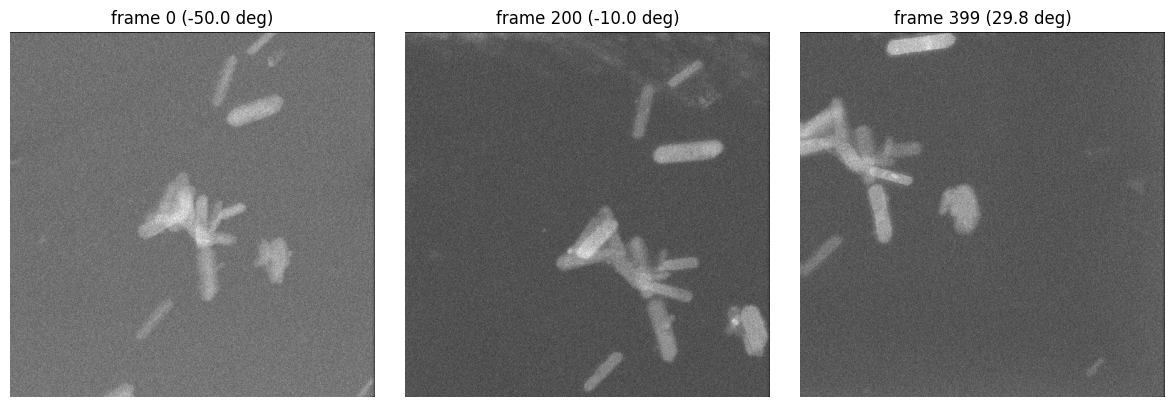

In [3]:
n = data.shape[0]
sample_idx = [0, n // 2, n - 1]

fig, axes = plt.subplots(1, len(sample_idx), figsize=(4 * len(sample_idx), 4))
for ax, idx in zip(axes, sample_idx):
    ax.imshow(data[idx], cmap="gray")
    ax.set_title(f"frame {idx} ({tilt_angles[idx]:.1f} deg)")
    ax.axis("off")
fig.tight_layout()

## 3. Compute per-frame centroids

`compute_centroids` background-subtracts (1st-percentile) each frame and computes its intensity-weighted (x, y) centroid. Plotting the trajectory on top of a reference frame should show the centroids scattered roughly along one direction — that's a visual preview of the tilt axis before we fit it.

array([[258.28823346, 261.8615952 ],
       [258.37883419, 261.8166228 ],
       [258.56065192, 263.35148918],
       [258.90909682, 262.65079637],
       [259.14810997, 262.59528399]])

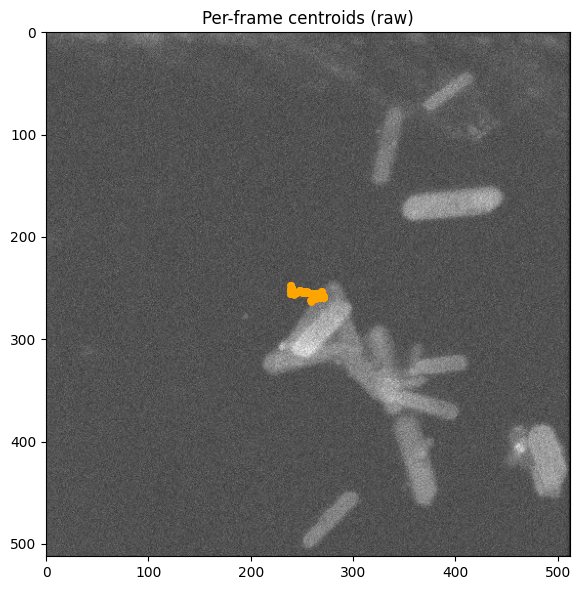

In [4]:
centroids = taf.compute_centroids(data)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(data[n // 2], cmap="gray")
ax.plot(centroids[:, 0], centroids[:, 1], "o-", color="orange", ms=4, lw=1)
ax.set_title("Per-frame centroids (raw)")
ax.set_xlim(0, data.shape[2])
ax.set_ylim(data.shape[1], 0)
fig.tight_layout()

centroids[:5]  # peek at the first few (x, y) pairs

## 4. PCA estimate of the tilt-axis angle

By the projection-slice theorem, the centroid coordinate *along* the true tilt axis is theoretically invariant with tilt angle, while the coordinate *perpendicular* to it sweeps back and forth. So the tilt axis is the **minimum-variance** direction of the centroid scatter — found here via PCA (eigendecomposition of the covariance matrix).

PCA tilt-axis angle estimate: 101.56 deg (0 deg = image +x axis)


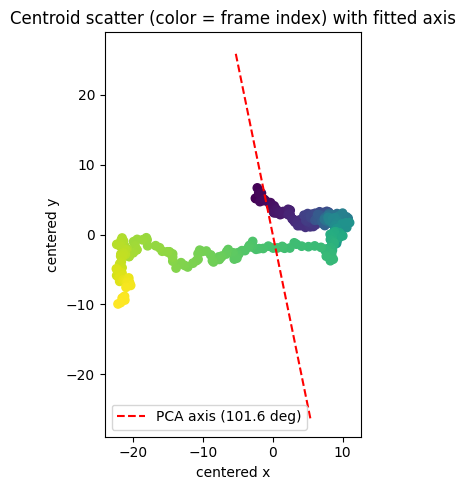

In [5]:
pca_angle, centered = taf.estimate_tilt_axis_pca(centroids)
print(f"PCA tilt-axis angle estimate: {pca_angle:.2f} deg (0 deg = image +x axis)")

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(centered[:, 0], centered[:, 1], c=np.arange(n), cmap="viridis")
phi = np.radians(pca_angle)
r = np.abs(centered).max() * 1.2
ax.plot([-r * np.cos(phi), r * np.cos(phi)], [-r * np.sin(phi), r * np.sin(phi)],
        "r--", label=f"PCA axis ({pca_angle:.1f} deg)")
ax.set_xlabel("centered x")
ax.set_ylabel("centered y")
ax.set_aspect("equal")
ax.legend()
ax.set_title("Centroid scatter (color = frame index) with fitted axis")
fig.tight_layout()

## 5. Cross-check: explicit angle sweep

An independent confirmation of the PCA result: try every candidate angle 0–180°, project the centered centroids onto it, and measure the variance. The minimum should land on (approximately) the same angle as the PCA estimate above.

Sweep-refined tilt-axis angle: 101.50 deg
(PCA vs sweep agreement: 0.06 deg difference)


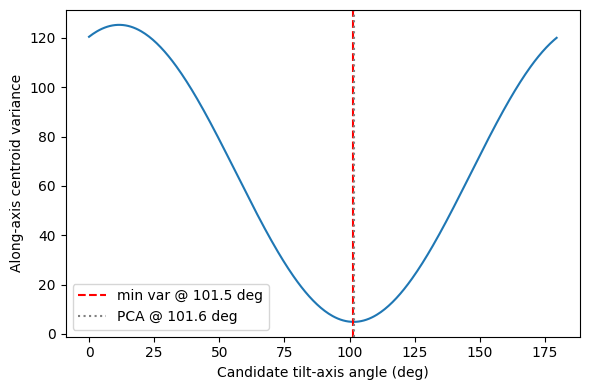

In [6]:
angles, variances, swept_angle = taf.sweep_tilt_axis_angle(centered)
print(f"Sweep-refined tilt-axis angle: {swept_angle:.2f} deg")
print(f"(PCA vs sweep agreement: {abs(pca_angle - swept_angle):.2f} deg difference)")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(angles, variances)
ax.axvline(swept_angle, color="red", ls="--", label=f"min var @ {swept_angle:.1f} deg")
ax.axvline(pca_angle, color="gray", ls=":", label=f"PCA @ {pca_angle:.1f} deg")
ax.set_xlabel("Candidate tilt-axis angle (deg)")
ax.set_ylabel("Along-axis centroid variance")
ax.legend()
fig.tight_layout()

## 5b. Cross-check: Radon-transform / common-line consistency (slower)

A second, independent method (`estimate_tilt_axis_radon`): instead of reducing each frame to a single centroid, it uses the *entire* projected 1-D intensity profile (one Radon-transform row per candidate angle per frame) - for the correct axis, that whole profile should stay nearly identical across tilts, not just its first moment. More robust to noise/asymmetric or low-contrast specimens than the centroid-only methods above, at the cost of being much slower (one Radon transform per frame per candidate angle).

To keep the runtime reasonable, this cell subsamples the tilt series (`STRIDE`) and uses a coarser angle step than the sweep above - tune both down if this is too slow, or up for a finer/more thorough check once you know roughly where the answer is. Genuine agreement between this and the PCA/sweep result above is much stronger evidence than either alone.

Radon/common-line tilt-axis angle estimate: 124.00 deg
(PCA vs Radon agreement: 22.44 deg difference)
(Sweep vs Radon agreement: 22.50 deg difference)


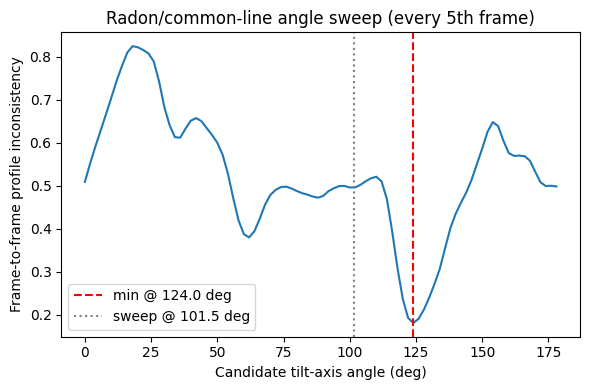

In [7]:
STRIDE = 5       # use every STRIDE-th frame - lower = slower but more accurate
RADON_STEP = 2.0  # candidate-angle step, in degrees

radon_angles, radon_scores, radon_axis_angle = taf.estimate_tilt_axis_radon(
    data[::STRIDE], step=RADON_STEP,
)
print(f"Radon/common-line tilt-axis angle estimate: {radon_axis_angle:.2f} deg")
print(f"(PCA vs Radon agreement: {abs(pca_angle - radon_axis_angle):.2f} deg difference)")
print(f"(Sweep vs Radon agreement: {abs(swept_angle - radon_axis_angle):.2f} deg difference)")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(radon_angles, radon_scores)
ax.axvline(radon_axis_angle, color="red", ls="--", label=f"min @ {radon_axis_angle:.1f} deg")
ax.axvline(swept_angle, color="gray", ls=":", label=f"sweep @ {swept_angle:.1f} deg")
ax.set_xlabel("Candidate tilt-axis angle (deg)")
ax.set_ylabel("Frame-to-frame profile inconsistency")
ax.set_title(f"Radon/common-line angle sweep (every {STRIDE}th frame)")
ax.legend()
fig.tight_layout()

## 6. Final result

A quick comparison of all three estimates, then the tilt axis overlaid on a reference frame (using the sweep-refined angle).

Tilt-axis angle estimates:
  PCA:              101.56 deg
  Sweep (refined):  101.50 deg
  Radon/common-line:124.00 deg


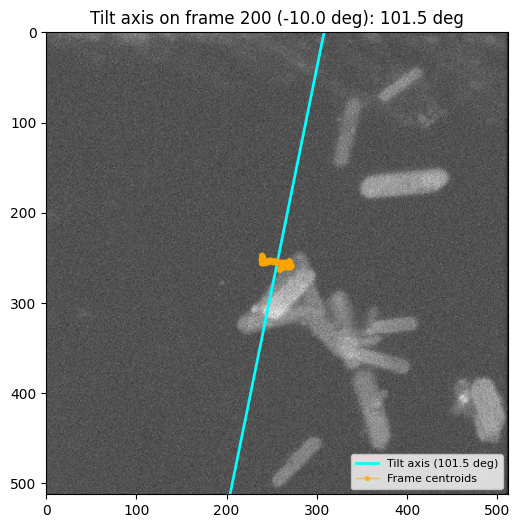

In [8]:
print("Tilt-axis angle estimates:")
print(f"  PCA:              {pca_angle:.2f} deg")
print(f"  Sweep (refined):  {swept_angle:.2f} deg")
print(f"  Radon/common-line:{radon_axis_angle:.2f} deg")

ref_idx = n // 2
taf.plot_tilt_axis(
    data[ref_idx], swept_angle, centroids=centroids,
    title=f"Tilt axis on frame {ref_idx} ({tilt_angles[ref_idx]:.1f} deg): {swept_angle:.1f} deg",
)
plt.show()

---
**Caveat:** both methods above are coarse, marker-free estimates. They assume the specimen rotates rigidly about a fixed in-plane axis with no frame-to-frame stage/beam translational drift - real data will have some drift, which adds noise to the centroid/profile trajectory and therefore to both estimates. If the angle-sweep curve in step 5 (or the Radon curve in step 5b) doesn't show a clean, single minimum, that's a sign drift or a weak/low-contrast specimen is corrupting the fit.

For production alignment/reconstruction, use a proper pipeline (IMOD, AreTomo, etc.) - if your data actually has fiducial markers (gold beads or other distinct high-contrast points), tracking *several* of them and jointly solving for one shared tilt axis (IMOD's `tiltalign`) is far more constrained/robust than anything here, which only ever uses one feature (the whole specimen) at a time.